In [1]:
!pip install "dacite~=1.6.0" mlflow dagshub lightgbm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 72.0 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 77.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import mlflow
import mlflow.lightgbm
import dagshub
import lightgbm as lgb
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline

RANDOM_STATE   = 42
REPO_OWNER     = 'ejoba22'
REPO_NAME      = 'IEEE-CIS-Fraud-Detection'
EXPERIMENT_NAME = 'LightGBM_Training'

dagshub.init(repo_owner=REPO_OWNER, repo_name=REPO_NAME, mlflow=True)

if mlflow.active_run() is not None:
    mlflow.end_run()

experiment   = mlflow.set_experiment(EXPERIMENT_NAME)
EXPERIMENT_ID = experiment.experiment_id

print('MLflow tracking URI:', mlflow.get_tracking_uri())
print('MLflow experiment:',   experiment.name)
print('MLflow experiment id:', EXPERIMENT_ID)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=4cc2c000-43e2-4bce-90b4-87e8ffe9ee3d&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=83210496a3633489eb30deca5cc0cf70ec4acf96b674c1bb2a7fb6236d5d450c




Accessing as ejoba22

Initialized MLflow to track repo "ejoba22/IEEE-CIS-Fraud-Detection"

Repository ejoba22/IEEE-CIS-Fraud-Detection initialized!

MLflow tracking URI: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow
MLflow experiment: LightGBM_Training
MLflow experiment id: 3


In [3]:
def reduce_mem_usage(df):
    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype
        if col_type == object:
            continue
        c_min = df[col].min()
        c_max = df[col].max()
        if str(col_type).startswith('int'):
            if c_min >= np.iinfo(np.int8).min and c_max <= np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif c_min >= np.iinfo(np.int16).min and c_max <= np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif c_min >= np.iinfo(np.int32).min and c_max <= np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
        elif str(col_type).startswith('float'):
            df[col] = df[col].astype(np.float32)
    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f'Memory reduced from {start_mem:.1f} MB to {end_mem:.1f} MB')
    return df


from pathlib import Path

DATA_DIR_CANDIDATES = [
    Path('/kaggle/input/competitions/ieee-fraud-detection'),
    Path('/kaggle/input/ieee-fraud-detection')
]

DATA_DIR = next(
    (path for path in DATA_DIR_CANDIDATES if (path / 'train_transaction.csv').exists()),
    None
)

if DATA_DIR is None:
    raise FileNotFoundError(
        'Could not find IEEE-CIS data. '
        f'Tried: {[str(path) for path in DATA_DIR_CANDIDATES]}'
    )

print('Using data directory:', DATA_DIR)

train_transaction = reduce_mem_usage(pd.read_csv(DATA_DIR / 'train_transaction.csv'))
train_identity    = reduce_mem_usage(pd.read_csv(DATA_DIR / 'train_identity.csv'))

train = train_transaction.merge(train_identity, on='TransactionID', how='left')
train = reduce_mem_usage(train)
print('Raw shape:', train.shape)

Using data directory: /kaggle/input/competitions/ieee-fraud-detection
Memory reduced from 2062.1 MB to 1203.2 MB
Memory reduced from 143.1 MB to 129.9 MB
Memory reduced from 1603.3 MB to 1603.3 MB
Raw shape: (590540, 434)


# Cleaning


In [4]:
train = train.sort_values('TransactionDT').reset_index(drop=True)
split_idx  = int(len(train) * 0.8)
df_tr_raw  = train.iloc[:split_idx].copy()
df_val_raw = train.iloc[split_idx:].copy()

df_tr  = df_tr_raw.copy()
df_val = df_val_raw.copy()

print(f'Train: {len(df_tr):,} rows  |  Val: {len(df_val):,} rows')

#Drop high-missing columns
LGBM_MISSING_THRESHOLD = 0.9
missing   = df_tr.isnull().mean()
drop_cols = missing[missing > LGBM_MISSING_THRESHOLD].index.tolist()
drop_cols += ['TransactionID', 'TransactionDT']

df_tr  = df_tr.drop(columns=drop_cols,  errors='ignore')
df_val = df_val.drop(columns=drop_cols, errors='ignore')

#Categorical encoding 
cat_cols = df_tr.select_dtypes('object').columns.tolist()
for col in cat_cols:
    df_tr[col]  = df_tr[col].fillna('missing').astype('category')
    df_val[col] = df_val[col].fillna('missing').astype('category')

print(f'Shape after cleaning: {df_tr.shape}')
print(f'Categorical columns:  {len(cat_cols)}')
print(f'Remaining NaNs in numeric cols: {df_tr.select_dtypes(include=np.number).isnull().sum().sum()}')

with mlflow.start_run(experiment_id=EXPERIMENT_ID, run_name='LightGBM_Cleaning'):
    mlflow.log_param('missing_threshold',  LGBM_MISSING_THRESHOLD)
    mlflow.log_param('imputation',         'none — LightGBM handles NaN natively')
    mlflow.log_param('cat_encoding',       'pandas category dtype (native LightGBM)')
    mlflow.log_param('dropped_cols',       len(drop_cols))
    mlflow.log_param('remaining_cols',     df_tr.shape[1])
    mlflow.log_param('cat_cols_count',     len(cat_cols))

Train: 472,432 rows  |  Val: 118,108 rows
Shape after cleaning: (472432, 420)
Categorical columns:  29
Remaining NaNs in numeric cols: 78675204
🏃 View run LightGBM_Cleaning at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3/runs/8baa7504f28e4fd8829196d197124e2f
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3


# Feature Engineering

In [5]:
def add_lgbm_features(df_feat, df_raw, feature_set='baseline'):
    df_feat = df_feat.copy()

    if feature_set == 'baseline':
        return df_feat

    # time_amount: log-amount + temporal features
    if feature_set in ('time_amount', 'time_amount_lgbm'):
        df_feat['TransactionAmt_log'] = np.log1p(df_raw['TransactionAmt'])
        dt = df_raw['TransactionDT']
        df_feat['Transaction_hour']    = (dt // 3600) % 24
        df_feat['Transaction_weekday'] = (dt // 86400) % 7
        df_feat['is_night_hour']       = df_feat['Transaction_hour'].between(1, 6).astype(np.int8)
        df_feat['amt_rounded']         = (df_raw['TransactionAmt'] % 1 == 0).astype(np.int8)

    if feature_set == 'time_amount_lgbm':
        df_feat['amt_x_hour'] = df_feat['TransactionAmt_log'] * df_feat['Transaction_hour']
        if 'D1' in df_feat.columns:
            df_feat['D1_na'] = df_feat['D1'].isna().astype(np.int8)
        c_cols = [c for c in df_feat.columns
                  if c.startswith('C') and df_feat[c].dtype != 'category']
        for col in c_cols:
            df_feat[f'{col}_log'] = np.log1p(df_feat[col].clip(lower=0))

    return df_feat


PROBE_PARAMS = dict(
    n_estimators=100, num_leaves=31, learning_rate=0.1,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)

feature_results = {}

for feature_set in ['baseline', 'time_amount', 'time_amount_lgbm']:
    with mlflow.start_run(experiment_id=EXPERIMENT_ID,
                          run_name=f'LightGBM_Feature_Engineering_{feature_set}'):
        df_tr_fe  = add_lgbm_features(df_tr,  df_tr_raw,  feature_set)
        df_val_fe = add_lgbm_features(df_val, df_val_raw, feature_set)

        X_probe_tr  = df_tr_fe.drop(columns=['isFraud'])
        y_probe_tr  = df_tr_fe['isFraud']
        X_probe_val = df_val_fe.drop(columns=['isFraud'])
        y_probe_val = df_val_fe['isFraud']

        probe = lgb.LGBMClassifier(**PROBE_PARAMS)
        probe.fit(X_probe_tr, y_probe_tr)

        train_auc = roc_auc_score(y_probe_tr,  probe.predict_proba(X_probe_tr)[:, 1])
        val_auc   = roc_auc_score(y_probe_val, probe.predict_proba(X_probe_val)[:, 1])

        mlflow.log_param('feature_set',  feature_set)
        mlflow.log_param('n_features',   X_probe_tr.shape[1])
        mlflow.log_metric('train_auc',   round(train_auc, 4))
        mlflow.log_metric('val_auc',     round(val_auc,   4))
        mlflow.log_metric('overfit_gap', round(train_auc - val_auc, 4))

        feature_results[feature_set] = val_auc
        print(f'[{feature_set}]  features={X_probe_tr.shape[1]}'
              f'  train={train_auc:.4f}  val={val_auc:.4f}')

BEST_FEATURE_SET = max(feature_results, key=feature_results.get)
print(f'\nBest feature set: {BEST_FEATURE_SET}')

df_tr  = add_lgbm_features(df_tr,  df_tr_raw,  BEST_FEATURE_SET)
df_val = add_lgbm_features(df_val, df_val_raw, BEST_FEATURE_SET)
print(f'Shape after feature engineering: {df_tr.shape}')

[baseline]  features=419  train=0.9485  val=0.9038
🏃 View run LightGBM_Feature_Engineering_baseline at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3/runs/0227b48bedd7428ab1a7516806a938bf
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3
[time_amount]  features=424  train=0.9483  val=0.9001
🏃 View run LightGBM_Feature_Engineering_time_amount at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3/runs/f628d07a53824d5b94698fb872490ec5
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3
[time_amount_lgbm]  features=440  train=0.9499  val=0.9029
🏃 View run LightGBM_Feature_Engineering_time_amount_lgbm at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3/runs/3e19cfde5518464cbc1cd3fe8862e23a
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3

Best feature set: baseline
Sh

# Feature Selection

In [6]:
X_tr_base  = df_tr.drop(columns=['isFraud'])
y_tr       = df_tr['isFraud']
X_val_base = df_val.drop(columns=['isFraud'])
y_val      = df_val['isFraud']

num_cols_fs = X_tr_base.select_dtypes(include=np.number).columns
low_var     = num_cols_fs[X_tr_base[num_cols_fs].var() < 0.01].tolist()
X_tr_novar  = X_tr_base.drop(columns=low_var)
X_val_novar = X_val_base.drop(columns=low_var)

probe_model = lgb.LGBMClassifier(
    n_estimators=100, num_leaves=31,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
probe_model.fit(X_tr_novar, y_tr)
importances = pd.Series(probe_model.feature_importances_, index=X_tr_novar.columns)

selection_configs = [
    ('all_features',     X_tr_base,  X_val_base),
    ('variance_only',    X_tr_novar, X_val_novar),
    ('importance_10pct', X_tr_novar.drop(columns=importances[importances <= importances.quantile(0.10)].index),
                         X_val_novar.drop(columns=importances[importances <= importances.quantile(0.10)].index)),
    ('importance_20pct', X_tr_novar.drop(columns=importances[importances <= importances.quantile(0.20)].index),
                         X_val_novar.drop(columns=importances[importances <= importances.quantile(0.20)].index)),
]

selection_results = {}

for sel_name, X_sel_tr, X_sel_val in selection_configs:
    with mlflow.start_run(experiment_id=EXPERIMENT_ID,
                          run_name=f'LightGBM_Feature_Selection_{sel_name}'):
        eval_model = lgb.LGBMClassifier(
            n_estimators=100, num_leaves=31,
            random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
        )
        eval_model.fit(X_sel_tr, y_tr)

        train_auc = roc_auc_score(y_tr,  eval_model.predict_proba(X_sel_tr)[:, 1])
        val_auc   = roc_auc_score(y_val, eval_model.predict_proba(X_sel_val)[:, 1])

        mlflow.log_param('selection_method', sel_name)
        mlflow.log_param('low_var_dropped',  len(low_var))
        mlflow.log_param('n_features',       X_sel_tr.shape[1])
        mlflow.log_metric('train_auc',       round(train_auc, 4))
        mlflow.log_metric('val_auc',         round(val_auc,   4))
        mlflow.log_metric('overfit_gap',     round(train_auc - val_auc, 4))

        selection_results[sel_name] = (val_auc, X_sel_tr, X_sel_val)
        print(f'[{sel_name}]  features={X_sel_tr.shape[1]}'
              f'  train={train_auc:.4f}  val={val_auc:.4f}')

BEST_SELECTION = max(selection_results, key=lambda k: selection_results[k][0])
X_tr  = selection_results[BEST_SELECTION][1]
X_val = selection_results[BEST_SELECTION][2]

print(f'\nBest selection: {BEST_SELECTION}')
print(f'Final feature count: {X_tr.shape[1]}')

[all_features]  features=419  train=0.9485  val=0.9038
🏃 View run LightGBM_Feature_Selection_all_features at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3/runs/95d15b1a465b467080bf494166ac6dc3
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3
[variance_only]  features=395  train=0.9511  val=0.9041
🏃 View run LightGBM_Feature_Selection_variance_only at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3/runs/05938bde0e1b48ecbc21336a50f98dc2
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3
[importance_10pct]  features=241  train=0.9511  val=0.9041
🏃 View run LightGBM_Feature_Selection_importance_10pct at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3/runs/3e22c67f543c4ab6b4f3cc17411717fb
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3
[importance_20pct]  feat

# Training

In [7]:
# Underfit: very high learning rate + few leaves 
with mlflow.start_run(experiment_id=EXPERIMENT_ID, run_name='LightGBM_Training_underfit'):
    model = lgb.LGBMClassifier(
        n_estimators=50,
        learning_rate=0.5,
        num_leaves=8,
        max_depth=3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    )
    model.fit(X_tr, y_tr)

    train_auc = roc_auc_score(y_tr,  model.predict_proba(X_tr)[:, 1])
    val_auc   = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

    mlflow.log_param('n_estimators',  50)
    mlflow.log_param('learning_rate', 0.5)
    mlflow.log_param('num_leaves',    8)
    mlflow.log_param('max_depth',     3)
    mlflow.log_param('note',          'intentional underfit — too few leaves, high lr')
    mlflow.log_metric('train_auc',    round(train_auc, 4))
    mlflow.log_metric('val_auc',      round(val_auc,   4))
    mlflow.log_metric('overfit_gap',  round(train_auc - val_auc, 4))

    print(f'[Underfit]  train={train_auc:.4f}  val={val_auc:.4f}  gap={train_auc-val_auc:.4f}')

[Underfit]  train=0.8345  val=0.7903  gap=0.0443
🏃 View run LightGBM_Training_underfit at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3/runs/37aad2214f444b44bce1b0d7c845d509
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3


In [8]:
# Overfit: too many leaves, no regularisation
# num_leaves=512 with no min_child_samples means trees memorise training data
with mlflow.start_run(experiment_id=EXPERIMENT_ID, run_name='LightGBM_Training_overfit'):
    model = lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.1,
        num_leaves=512,
        min_child_samples=1,
        reg_alpha=0,
        reg_lambda=0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    )
    model.fit(X_tr, y_tr)

    train_auc = roc_auc_score(y_tr,  model.predict_proba(X_tr)[:, 1])
    val_auc   = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

    mlflow.log_param('n_estimators',      500)
    mlflow.log_param('learning_rate',     0.1)
    mlflow.log_param('num_leaves',        512)
    mlflow.log_param('min_child_samples', 1)
    mlflow.log_param('reg_alpha',         0)
    mlflow.log_param('reg_lambda',        0)
    mlflow.log_param('note',              'intentional overfit — too many leaves, no regularisation')
    mlflow.log_metric('train_auc',        round(train_auc, 4))
    mlflow.log_metric('val_auc',          round(val_auc,   4))
    mlflow.log_metric('overfit_gap',      round(train_auc - val_auc, 4))

    print(f'[Overfit]  train={train_auc:.4f}  val={val_auc:.4f}  gap={train_auc-val_auc:.4f}')

[Overfit]  train=0.5005  val=0.4742  gap=0.0264
🏃 View run LightGBM_Training_overfit at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3/runs/b50e8e8a21ea48fcb078d89be266629e
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3


In [9]:
# Tuned: grid search over key LightGBM hyperparameters 

best_val_auc      = 0
best_num_leaves   = None
best_min_child    = None
best_reg_lambda   = None

for num_leaves in [31, 63, 127]:
    for min_child_samples in [20, 100]:
        for reg_lambda in [0.0, 1.0]:
            run_name = f'LightGBM_Training_leaves{num_leaves}_child{min_child_samples}_l2{reg_lambda}'
            with mlflow.start_run(experiment_id=EXPERIMENT_ID, run_name=run_name):
                model = lgb.LGBMClassifier(
                    n_estimators=500,
                    learning_rate=0.05,
                    num_leaves=num_leaves,
                    min_child_samples=min_child_samples,
                    reg_lambda=reg_lambda,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                    verbose=-1
                )
                model.fit(
                    X_tr, y_tr,
                    eval_set=[(X_val, y_val)],
                    callbacks=[lgb.early_stopping(50, verbose=False),
                               lgb.log_evaluation(-1)]
                )

                train_auc = roc_auc_score(y_tr,  model.predict_proba(X_tr)[:, 1])
                val_auc   = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

                mlflow.log_param('n_estimators',      model.best_iteration_)
                mlflow.log_param('learning_rate',     0.05)
                mlflow.log_param('num_leaves',        num_leaves)
                mlflow.log_param('min_child_samples', min_child_samples)
                mlflow.log_param('reg_lambda',        reg_lambda)
                mlflow.log_param('subsample',         0.8)
                mlflow.log_param('colsample_bytree',  0.8)
                mlflow.log_metric('train_auc',        round(train_auc, 4))
                mlflow.log_metric('val_auc',          round(val_auc,   4))
                mlflow.log_metric('overfit_gap',      round(train_auc - val_auc, 4))
                mlflow.log_metric('best_iteration',   model.best_iteration_)

                print(f'[leaves={num_leaves} child={min_child_samples} l2={reg_lambda}]  '
                      f'train={train_auc:.4f}  val={val_auc:.4f}  gap={train_auc-val_auc:.4f}  '
                      f'iters={model.best_iteration_}')

                if val_auc > best_val_auc:
                    best_val_auc    = val_auc
                    best_num_leaves = num_leaves
                    best_min_child  = min_child_samples
                    best_reg_lambda = reg_lambda

print(f'\nBest: leaves={best_num_leaves}  child={best_min_child}  l2={best_reg_lambda}  val_AUC={best_val_auc:.4f}')

[leaves=31 child=20 l2=0.0]  train=0.9708  val=0.9116  gap=0.0592  iters=497
🏃 View run LightGBM_Training_leaves31_child20_l20.0 at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3/runs/d87ed9f52c7a4f14b8422fe6bd486f35
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3
[leaves=31 child=20 l2=1.0]  train=0.9656  val=0.9093  gap=0.0563  iters=500
🏃 View run LightGBM_Training_leaves31_child20_l21.0 at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3/runs/1462141e49bf44a79b5baea4058de8ee
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3
[leaves=31 child=100 l2=0.0]  train=0.9675  val=0.9120  gap=0.0555  iters=499
🏃 View run LightGBM_Training_leaves31_child100_l20.0 at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3/runs/2e48ce53496b449ab0729ce5829c3088
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fr

In [10]:
#Cross-validation with best hyperparameters 
N_CV_SPLITS = 5
cv          = TimeSeriesSplit(n_splits=N_CV_SPLITS)
cv_scores   = []

for fold, (tr_idx, val_idx) in enumerate(cv.split(X_tr)):
    X_fold_tr,  X_fold_val = X_tr.iloc[tr_idx], X_tr.iloc[val_idx]
    y_fold_tr,  y_fold_val = y_tr.iloc[tr_idx], y_tr.iloc[val_idx]

    cv_model = lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=best_num_leaves,
        min_child_samples=best_min_child,
        reg_lambda=best_reg_lambda,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    )
    cv_model.fit(
        X_fold_tr, y_fold_tr,
        eval_set=[(X_fold_val, y_fold_val)],
        callbacks=[lgb.early_stopping(50, verbose=False),
                   lgb.log_evaluation(-1)]
    )
    fold_auc = roc_auc_score(y_fold_val, cv_model.predict_proba(X_fold_val)[:, 1])
    cv_scores.append(fold_auc)
    print(f'  Fold {fold+1}: AUC={fold_auc:.4f}')

cv_mean = np.mean(cv_scores)
cv_std  = np.std(cv_scores)

with mlflow.start_run(experiment_id=EXPERIMENT_ID, run_name='LightGBM_CrossValidation'):
    mlflow.log_param('cv_strategy',      'TimeSeriesSplit')
    mlflow.log_param('n_splits',         N_CV_SPLITS)
    mlflow.log_param('num_leaves',       best_num_leaves)
    mlflow.log_param('min_child_samples', best_min_child)
    mlflow.log_param('reg_lambda',       best_reg_lambda)
    mlflow.log_metric('cv_auc_mean',     round(cv_mean, 4))
    mlflow.log_metric('cv_auc_std',      round(cv_std,  4))
    for i, s in enumerate(cv_scores):
        mlflow.log_metric(f'cv_fold_{i+1}_auc', round(s, 4))

print(f'\nCV AUC ({N_CV_SPLITS}-fold TimeSeriesSplit): {cv_mean:.4f} ± {cv_std:.4f}')
print(f'Individual folds: {[round(s, 4) for s in cv_scores]}')

  Fold 1: AUC=0.8994
  Fold 2: AUC=0.9119
  Fold 3: AUC=0.9175
  Fold 4: AUC=0.9097
  Fold 5: AUC=0.9313
🏃 View run LightGBM_CrossValidation at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3/runs/91bb1fe1ec6f42f68738f3c90adea45d
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3

CV AUC (5-fold TimeSeriesSplit): 0.9139 ± 0.0105
Individual folds: [np.float64(0.8994), np.float64(0.9119), np.float64(0.9175), np.float64(0.9097), np.float64(0.9313)]


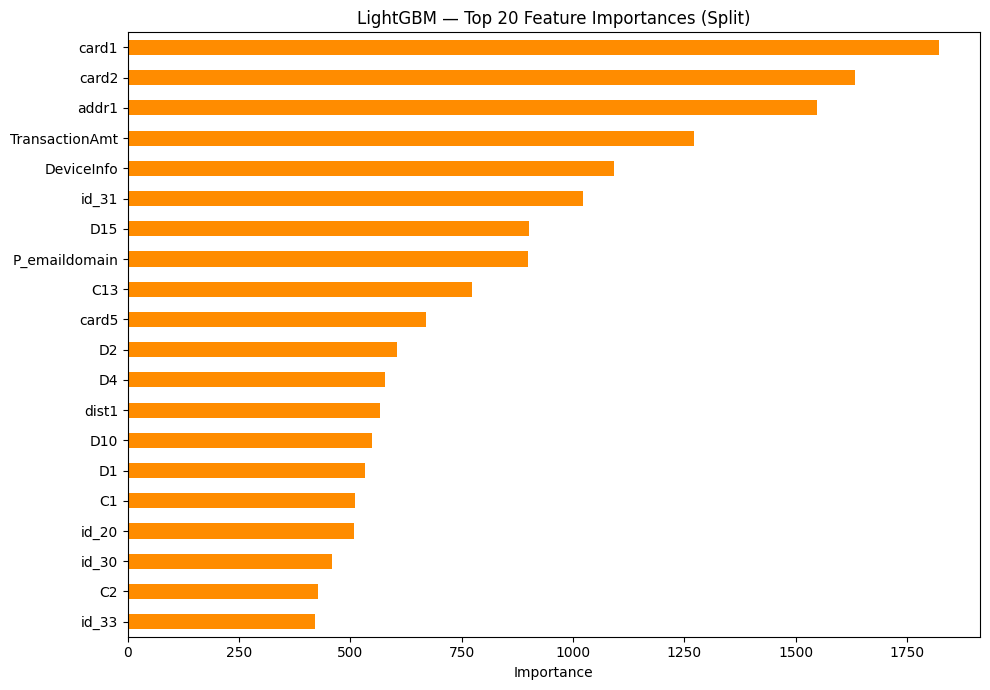

Top 10 features:
card1             1823
card2             1633
addr1             1547
TransactionAmt    1272
DeviceInfo        1091
id_31             1023
D15                901
P_emaildomain      898
C13                774
card5              670
dtype: int32


In [11]:
# Feature importance plot from best tuned model 
best_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=best_num_leaves,
    min_child_samples=best_min_child,
    reg_lambda=best_reg_lambda,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)
best_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(-1)]
)

importances = pd.Series(best_model.feature_importances_, index=X_tr.columns)
top20       = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 7))
top20.sort_values().plot(kind='barh', color='darkorange')
plt.title('LightGBM — Top 20 Feature Importances (Split)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('lgbm_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print('Top 10 features:')
print(top20.head(10))

In [12]:
#Build and register final Pipeline 

class LightGBMFraudPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, missing_threshold=0.9, low_variance_threshold=0.01,
                 feature_set='time_amount_lgbm', selection_strategy='importance_10pct',
                 importance_quantile=0.10):
        self.missing_threshold      = missing_threshold
        self.low_variance_threshold = low_variance_threshold
        self.feature_set            = feature_set
        self.selection_strategy     = selection_strategy
        self.importance_quantile    = importance_quantile

    def _base_transform(self, X):
        d = X.drop(columns=self.drop_cols_, errors='ignore').copy()
        d = d.drop(columns=['isFraud'], errors='ignore')

        if self.feature_set in ('time_amount', 'time_amount_lgbm'):
            if 'TransactionAmt' in X.columns:
                d['TransactionAmt_log'] = np.log1p(X['TransactionAmt'])
                d['amt_rounded']        = (X['TransactionAmt'] % 1 == 0).astype(np.int8)
            if 'TransactionDT' in X.columns:
                dt = X['TransactionDT']
                d['Transaction_hour']    = (dt // 3600) % 24
                d['Transaction_weekday'] = (dt // 86400) % 7
                d['is_night_hour']       = d['Transaction_hour'].between(1, 6).astype(np.int8)

        if self.feature_set == 'time_amount_lgbm':
            if 'TransactionAmt_log' in d.columns and 'Transaction_hour' in d.columns:
                d['amt_x_hour'] = d['TransactionAmt_log'] * d['Transaction_hour']
            if 'D1' in d.columns:
                d['D1_na'] = d['D1'].isna().astype(np.int8)
            c_cols = [c for c in d.columns if c.startswith('C') and d[c].dtype != 'category']
            for col in c_cols:
                d[f'{col}_log'] = np.log1p(d[col].clip(lower=0))

        for col in d.select_dtypes('object').columns:
            d[col] = d[col].fillna('missing').astype('category')

        for col in d.select_dtypes('float64').columns:
            d[col] = d[col].astype('float32')

        return d

    def fit(self, X, y=None):
        miss = X.isnull().mean()
        self.drop_cols_ = miss[miss > self.missing_threshold].index.tolist()
        self.drop_cols_ += ['TransactionID', 'TransactionDT']

        d = self._base_transform(X)

        if self.selection_strategy != 'all_features':
            num_cols = d.select_dtypes(include=np.number).columns
            self.low_var_cols_ = num_cols[d[num_cols].var() < self.low_variance_threshold].tolist()
        else:
            self.low_var_cols_ = []
        d = d.drop(columns=self.low_var_cols_, errors='ignore')

        if self.selection_strategy in ('importance_10pct', 'importance_20pct') and y is not None:
            probe = lgb.LGBMClassifier(
                n_estimators=100, num_leaves=31,
                random_state=42, n_jobs=-1, verbose=-1
            )
            probe.fit(d, y)
            imp = pd.Series(probe.feature_importances_, index=d.columns)
            threshold = imp.quantile(self.importance_quantile)
            self.low_importance_cols_ = imp[imp <= threshold].index.tolist()
        else:
            self.low_importance_cols_ = []
        d = d.drop(columns=self.low_importance_cols_, errors='ignore')

        self.feature_columns_ = d.columns.tolist()

        self.cat_categories_ = {
            col: d[col].cat.categories.tolist()
            for col in d.select_dtypes('category').columns
        }

        return self

    def transform(self, X):
        d = self._base_transform(X)
        d = d.drop(columns=self.low_var_cols_,        errors='ignore')
        d = d.drop(columns=self.low_importance_cols_,  errors='ignore')
        d = d.reindex(columns=self.feature_columns_,  fill_value=0)

        for col, cats in self.cat_categories_.items():
            if col in d.columns:
                d[col] = d[col].astype(str).where(
                    d[col].notna(), 'missing'
                )
                d[col] = pd.Categorical(d[col], categories=cats)

        return d


required_vars = ['best_num_leaves', 'best_min_child', 'best_reg_lambda',
                 'BEST_FEATURE_SET', 'BEST_SELECTION',
                 'df_tr_raw', 'df_val_raw', 'EXPERIMENT_ID']
missing_vars  = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise RuntimeError(f'Run earlier cells first. Missing: {missing_vars}')

_quantile_map = {'importance_10pct': 0.10, 'importance_20pct': 0.20}

final_pipeline = Pipeline(steps=[
    ('preprocess', LightGBMFraudPreprocessor(
        missing_threshold=LGBM_MISSING_THRESHOLD,
        low_variance_threshold=0.01,
        feature_set=BEST_FEATURE_SET,
        selection_strategy=BEST_SELECTION,
        importance_quantile=_quantile_map.get(BEST_SELECTION, 0.10)
    )),
    ('model', lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=best_num_leaves,
        min_child_samples=best_min_child,
        reg_lambda=best_reg_lambda,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    ))
])

with mlflow.start_run(experiment_id=EXPERIMENT_ID, run_name='LightGBM_Final_Pipeline_Register'):
    X_train_raw = df_tr_raw.drop(columns=['isFraud'])
    y_train_raw = df_tr_raw['isFraud']
    X_val_raw   = df_val_raw.drop(columns=['isFraud'])
    y_val_raw   = df_val_raw['isFraud']

    final_pipeline.fit(X_train_raw, y_train_raw)

    train_auc = roc_auc_score(y_train_raw, final_pipeline.predict_proba(X_train_raw)[:, 1])
    val_auc   = roc_auc_score(y_val_raw,   final_pipeline.predict_proba(X_val_raw)[:, 1])
    gap       = train_auc - val_auc

    mlflow.log_param('n_estimators',        500)
    mlflow.log_param('learning_rate',       0.05)
    mlflow.log_param('num_leaves',          best_num_leaves)
    mlflow.log_param('min_child_samples',   best_min_child)
    mlflow.log_param('reg_lambda',          best_reg_lambda)
    mlflow.log_param('subsample',           0.8)
    mlflow.log_param('colsample_bytree',    0.8)
    mlflow.log_param('missing_threshold',   LGBM_MISSING_THRESHOLD)
    mlflow.log_param('imputation',          'none — LightGBM handles NaN natively')
    mlflow.log_param('cat_encoding',        'pandas category dtype (native LightGBM)')
    mlflow.log_param('feature_engineering', BEST_FEATURE_SET)
    mlflow.log_param('feature_selection',   BEST_SELECTION)
    mlflow.log_metric('train_auc',          round(train_auc, 4))
    mlflow.log_metric('val_auc',            round(val_auc,   4))
    mlflow.log_metric('overfit_gap',        round(gap,       4))

    mlflow.sklearn.log_model(
        sk_model=final_pipeline,
        artifact_path='lightgbm_pipeline',
        registered_model_name='IEEE_CIS_LightGBM_Best'
    )

    print(f'Final pipeline — train={train_auc:.4f}  val={val_auc:.4f}  gap={gap:.4f}')
    print('Registered to Model Registry as: IEEE_CIS_LightGBM_Best')

2026/05/05 20:13:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/05 20:14:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'IEEE_CIS_LightGBM_Best' already exists. Creating a new version of this model...
2026/05/05 20:14:21 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: IEEE_CIS_LightGBM_Best, version 2
Created version '2' of model 'IEEE_CIS_LightGBM_Best'.


Final pipeline — train=0.9952  val=0.9195  gap=0.0757
Registered to Model Registry as: IEEE_CIS_LightGBM_Best
🏃 View run LightGBM_Final_Pipeline_Register at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3/runs/65c86645450b4767952974882b8dca81
🧪 View experiment at: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3
